In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df= pd.read_csv('C:/Users/Shreni/OneDrive/Desktop/AI-Product-Development/AIPD_Datasets/spotify_data clean.csv')
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [3]:
df.info

<bound method DataFrame.info of                     track_id                                       track_name  \
0     3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)   
1     1oQW6G2ZiwMuHqlPpP27DB                                             OMG!   
2     7mdkjzoIYlf1rx9EtBpGmU                                      Hard 2 Find   
3     67rW0Zl7oB3qEpD5YWWE5w  Still Get Like That (ft. Project Pat & Starrah)   
4     15xptTfRBrjsppW0INUZjf                            ride me like a harley   
...                      ...                                              ...   
8577  0AQquaENerGps8BQmbPw14                                         Big Iron   
8578  4f8hBeMXMvssn6HtFAtblo                                          El Paso   
8579  0Vy7wsXNFrbNc6UTWoScnM                                 Over the Rainbow   
8580  760clbeDBWmBsBLbszWuNZ                                        I'm A Man   
8581  61GEP8lryEfcuEgBMbRmNi                               Alone And Forsaken

In [4]:
df.describe

<bound method NDFrame.describe of                     track_id                                       track_name  \
0     3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)   
1     1oQW6G2ZiwMuHqlPpP27DB                                             OMG!   
2     7mdkjzoIYlf1rx9EtBpGmU                                      Hard 2 Find   
3     67rW0Zl7oB3qEpD5YWWE5w  Still Get Like That (ft. Project Pat & Starrah)   
4     15xptTfRBrjsppW0INUZjf                            ride me like a harley   
...                      ...                                              ...   
8577  0AQquaENerGps8BQmbPw14                                         Big Iron   
8578  4f8hBeMXMvssn6HtFAtblo                                          El Paso   
8579  0Vy7wsXNFrbNc6UTWoScnM                                 Over the Rainbow   
8580  760clbeDBWmBsBLbszWuNZ                                        I'm A Man   
8581  61GEP8lryEfcuEgBMbRmNi                               Alone And Forsak

In [5]:
df['popular'] =df['track_popularity'].apply(lambda x:1 if x>=60 else 0)

In [6]:
print("Null values before handling:")
print(df.isnull().sum())
print("Shape before null value handling")
df.shape

Null values before handling:
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
popular                  0
dtype: int64
Shape before null value handling


(8582, 16)

In [7]:
df.fillna(df.median(numeric_only=True), inplace=True)

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,popular
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55,0
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07,0
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55,0
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69,0
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8577,0AQquaENerGps8BQmbPw14,Big Iron,1,71,False,Marty Robbins,60,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,3.92,1
8578,4f8hBeMXMvssn6HtFAtblo,El Paso,10,64,False,Marty Robbins,61,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,4.32,1
8579,0Vy7wsXNFrbNc6UTWoScnM,Over the Rainbow,5,8,False,The Mystics,27,18184,doo-wop,2ifB9Xjp9DdpqLlYlY60QW,Presenting The Mystics,1959-02-11,9,compilation,2.28,0
8580,760clbeDBWmBsBLbszWuNZ,I'm A Man,2,55,False,Bo Diddley,44,333376,"blues, classic blues, rock and roll, rockabilly",1cbtDEwxCjMhglb49OgNBR,Bo Diddley,1958-01-01,12,album,2.74,0


In [8]:
print("Null values after handling:")
print(df.isnull().sum())
print("Shape after null value handling")
df.shape

Null values after handling:
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
popular                  0
dtype: int64
Shape after null value handling


(8582, 16)

In [9]:
def remove_outliers(df):
    df = df.copy()
    for col in df.select_dtypes(include=[np.number]).columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df = remove_outliers(df)

In [10]:
print("Shape after outlier removal:")
df.shape

Shape after outlier removal:


(6714, 16)

In [11]:
le = LabelEncoder()
df['explicit']= le.fit_transform(df['explicit'])
df['album_type']= le.fit_transform(df['album_type'])

In [12]:
features = [
"artist_popularity",
"artist_followers",
"track_duration_min",
"album_total_tracks",
"explicit",
"album_type"
]

x = df[features]
y = df["popular"]

In [13]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)

In [14]:
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [15]:
lr= LogisticRegression(max_iter=100)
lr.fit(x_train_scaled, y_train)
lr_pred= lr.predict(x_test)

c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [16]:
svm= SVC()
svm.fit(x_train_scaled, y_train)
svm_pred= svm.predict(x_test)

c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [17]:
rf= RandomForestClassifier()
rf.fit(x_train_scaled, y_train)
rf_pred= rf.predict(x_test)

c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [18]:
def evaluate_model(model_name, y_test, y_pred):
    print(f"\n {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix\n", confusion_matrix(y_test, y_pred))

In [19]:
evaluate_model("random forest", y_test, rf_pred)


 random forest
Accuracy: 0.47133283693224126
Precision: 0.22215464317059475
Recall: 0.47133283693224126
F1 Score: 0.30197741475517076

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       710
           1       0.47      1.00      0.64       633

    accuracy                           0.47      1343
   macro avg       0.24      0.50      0.32      1343
weighted avg       0.22      0.47      0.30      1343


Confusion Matrix
 [[  0 710]
 [  0 633]]


c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [20]:
evaluate_model("logistic", y_test, lr_pred)


 logistic
Accuracy: 0.5279225614296351
Precision: 0.27930329255964303
Recall: 0.5279225614296351
F1 Score: 0.36532652886456235

Classification Report:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69       710
           1       0.00      0.00      0.00       633

    accuracy                           0.53      1343
   macro avg       0.26      0.50      0.35      1343
weighted avg       0.28      0.53      0.37      1343


Confusion Matrix
 [[709   1]
 [633   0]]


In [21]:
evaluate_model("SVM", y_test, svm_pred)


 SVM
Accuracy: 0.47133283693224126
Precision: 0.22215464317059475
Recall: 0.47133283693224126
F1 Score: 0.30197741475517076

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       710
           1       0.47      1.00      0.64       633

    accuracy                           0.47      1343
   macro avg       0.24      0.50      0.32      1343
weighted avg       0.22      0.47      0.30      1343


Confusion Matrix
 [[  0 710]
 [  0 633]]


c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [22]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train_scaled,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2
)

c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6532 - loss: 0.6096 - val_accuracy: 0.6865 - val_loss: 0.5752
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6867 - loss: 0.5679 - val_accuracy: 0.6940 - val_loss: 0.5649
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6925 - loss: 0.5613 - val_accuracy: 0.6893 - val_loss: 0.5615
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6939 - loss: 0.5588 - val_accuracy: 0.6930 - val_loss: 0.5628
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6909 - loss: 0.5571 - val_accuracy: 0.6958 - val_loss: 0.5602
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6974 - loss: 0.5554 - val_accuracy: 0.6995 - val_loss: 0.5603
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6948 - loss: 0.5537 - val_accuracy: 0.7005 - val_loss: 0.5601
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6969 - loss: 0.5530 - val_accuracy: 0.

In [23]:
loss, acc= model.evaluate(x_test_scaled, y_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6850 - loss: 0.5590


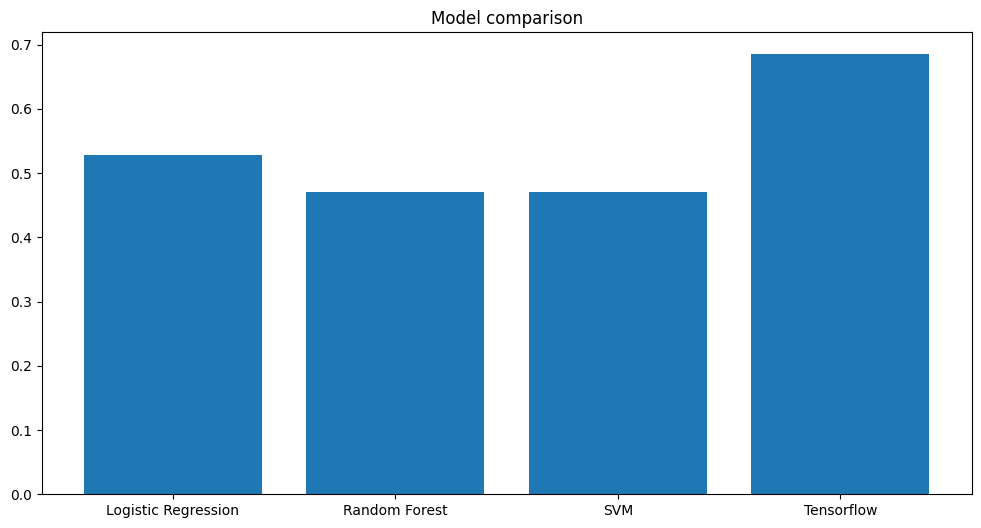

In [25]:
results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Tensorflow": acc
}

plt.figure(figsize=(12,6))
plt.bar(results.keys(), results.values())
plt.title("Model comparison")
plt.show()

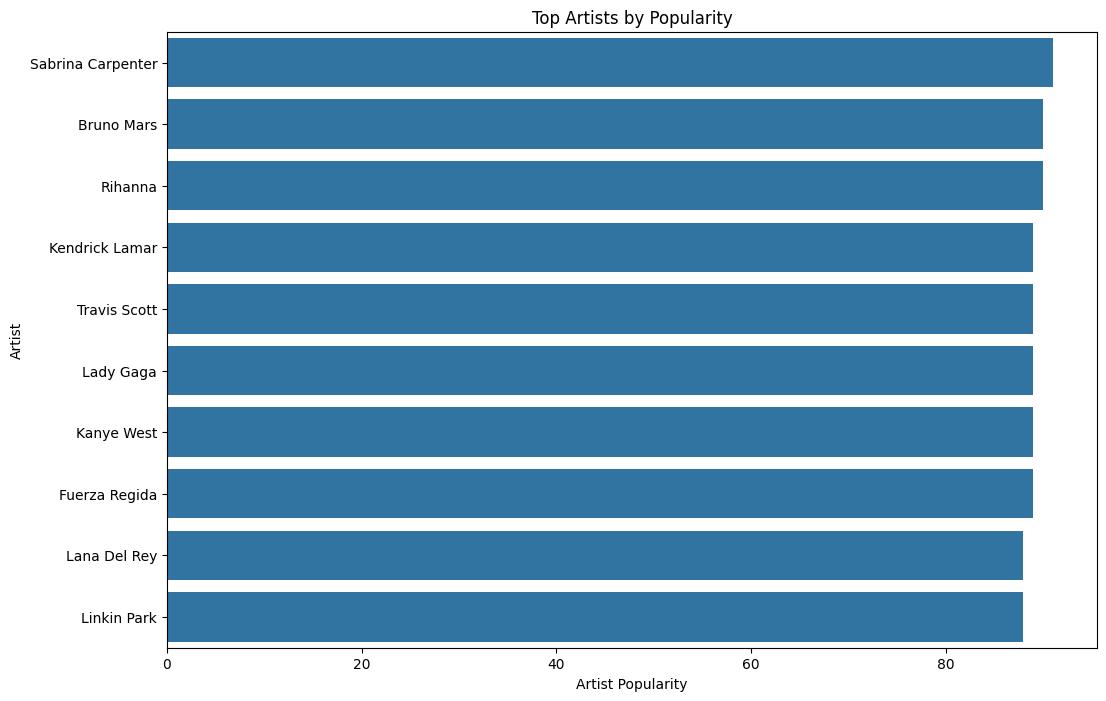

In [29]:
top_artists= df.sort_values(
    by="artist_popularity",
    ascending=False
).drop_duplicates("artist_name").head(10)

plt.figure(figsize=(12,8))

sns.barplot(
    x="artist_popularity",
    y="artist_name",
    data= top_artists
)

plt.title("Top Artists by Popularity")
plt.xlabel("Artist Popularity")
plt.ylabel("Artist")

plt.show()

In [30]:
artist_popularity = float(input("Artist popularity: "))
artist_followers = float(input("Artist followers: "))
duration = float(input("Track duration (min): "))
album_tracks = int(input("Album total tracks: "))
explicit = int(input("Explicit (0=No,1=Yes): "))
album_type = int(input("Album type (encoded): "))

sample = [[artist_popularity,artist_followers,duration,
album_tracks,explicit,album_type]]

sample = scaler.transform(sample)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Prediction: Popular Track")
else:
    print("Prediction: Not Popular")

Prediction: Not Popular


c:\Users\Shreni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
